In [1]:
# Regular Python library imports 
import xarray as xr 
import numpy as np
import pandas as pd
import pyproj
import scipy.interpolate
import matplotlib.pyplot as plt
import glob
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import os

# Helper functions for reading the data from the bucket and plotting
from utils.read_data_utils import read_IS2SITMOGR4, read_book_data
from utils.plotting_utils import static_winter_comparison_lineplot, staticArcticMaps, interactiveArcticMaps, compute_gridcell_winter_means, interactive_winter_comparison_lineplot # Plotting utils 
from utils.extra_funcs import read_IS2SITMOGR4S, regrid_ubris_to_is2, get_cs2is2_snow, apply_interpolation_time
# Plotting dependencies
#%config InlineBackend.figure_format = 'retina'
import matplotlib as mpl

# Remove warnings to improve display
import warnings 
warnings.filterwarnings('ignore') 

# Get the current working directory
current_directory = os.getcwd()

In [2]:
# Load the winter IS-2 thickness data from zarr/s3
IS2SITMOGR4_v3 = read_IS2SITMOGR4(data_type='netcdf-local', version='V4') 
#IS2SITMOGR4_v3

In [3]:
# Get some IS2 map projection/domain info needed for later functions
out_proj = 'EPSG:3411'
mapProj = pyproj.Proj("+init=" + out_proj)

xIS2 = IS2SITMOGR4_v3.x.values
yIS2 = IS2SITMOGR4_v3.y.values
xptsIS2, yptsIS2 = np.meshgrid(xIS2, yIS2)
out_lons = IS2SITMOGR4_v3.longitude.values
out_lats = IS2SITMOGR4_v3.latitude.values

In [4]:
IS2SITMOGR4_v3

<xarray.Dataset> Size: 361MB
Dimensions:                      (time: 22, y: 448, x: 304)
Coordinates:
  * time                         (time) datetime64[ns] 176B 2018-11-01 ... 20...
    longitude                    (y, x) float32 545kB 168.3 168.1 ... -9.999
    latitude                     (y, x) float32 545kB 31.1 31.2 ... 34.58 34.47
  * x                            (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                            (y) float32 2kB 5.838e+06 ... -5.338e+06
Data variables: (12/31)
    crs                          (time) int32 88B -2147483647 ... -2147483647
    ice_thickness                (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth                   (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_J22            (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density                 (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_SM_E5dist      (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                           ...
    ice_density_J22              (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_mW99rdist      (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mW99rdist_int     (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_mW99rdist_int  (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                 (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                  (time, y, x) float32 12MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 V4 dataset.
    reference:    Official NSIDC data doi: 10.5067/CV6JEXEE31HF. Derived data...
    history:      Created 06/08/25

In [5]:
rename_dict = {
    'snow_depth_SM_E5dist': 'snow_depth_sm_e5',
    'snow_depth_SM_E5dist_int': 'snow_depth_sm_e5_int',
    'snow_depth_SM_M2dist': 'snow_depth_sm_m2',
    'snow_depth_SM_M2dist_int': 'snow_depth_sm_m2_int',
    'ice_thickness_SM_E5dist': 'ice_thickness_sm_e5',
    'ice_thickness_SM_E5dist_int': 'ice_thickness_sm_e5_int',
    'ice_thickness_SM_M2dist': 'ice_thickness_sm_m2',
    'ice_thickness_SM_M2dist_int': 'ice_thickness_sm_m2_int',
    'snow_depth_mW99rdist': 'snow_depth_mw99r',
    'snow_depth_mW99rdist_int': 'snow_depth_mw99r_int',
    'ice_thickness_mW99rdist': 'ice_thickness_mw99r',
    'ice_thickness_mW99rdist_int': 'ice_thickness_mw99r_int',
    'snow_density_W99r': 'snow_density_w99r',
    'snow_density_SM_E5': 'snow_density_sm_e5',
    'snow_density_SM_M2': 'snow_density_sm_m2',
    'ice_density_J22': 'ice_density_j22',
    'ice_thickness_J22': 'ice_thickness_j22',
    'ice_thickness_J22_int': 'ice_thickness_j22_int',
    'ice_density_1': 'ice_density'

    # Add more if needed
}
IS2SITMOGR4_v3 = IS2SITMOGR4_v3.rename(rename_dict)

In [6]:
# interpolate variables unique to the winter dataset (the sm data are already interpolated in summer and summer has no modified warren data)

#IS2SITMOGR4_v3 = apply_interpolation_time(IS2SITMOGR4_v3, xptsIS2, yptsIS2, ['snow_depth_sm', 'ice_thickness_sm', 'snow_depth_mw99', 'ice_thickness_mw99'])

In [7]:
# Read in the new summer IS-2 thickness data locally (not on s3 yet)
IS2SITMOGR4_summer_v0 = read_IS2SITMOGR4S(local_data_path="./data/IS2SITMOGR4S/")


./data/IS2SITMOGR4S/V1/*.nc


In [8]:
IS2SITMOGR4_summer_v0.variables

Frozen({'crs': <xarray.Variable (time: 11)> Size: 44B
array([-2147483647, -2147483647, -2147483647, -2147483647, -2147483647,
       -2147483647, -2147483647, -2147483647, -2147483647, -2147483647,
       -2147483647], dtype=int32)
Attributes: (12/23)
    long_name:                              NSIDC Sea Ice Polar Stereographic...
    proj4text:                              +proj=stere +lat_0=90 +lat_ts=70 ...
    spatial_ref:                            PROJCS["NSIDC Sea Ice Polar Stere...
    grid_mapping_name:                      polar_stereographic
    srid:                                   urn:ogc:def:crs:EPSG::3411
    GeoTransform:                           -3850000.0 25000.0 0 5850000.0 0 ...
    ...                                     ...
    parent_grid_cell_row_subset_end:        448.0
    parent_grid_cell_column_subset_start:   0.0
    parent_grid_cell_column_subset_end:     304.0
    units:                                  meters
    semimajor_radius:                     

In [9]:
#rename_dict = {
#    'snow_depth_w99r': 'snow_depth_W99r',
#    'snow_depth_w99r_int': 'snow_depth_W99r_int',
#    'snow_density_w99r': 'snow_density_W99r',
#    'ice_thickness_w99r': 'ice_thickness_W99r',
#    'ice_thickness_w99r_int': 'ice_thickness_W99r_int',
#    # Add more if needed
#}
#IS2SITMOGR4_summer_v0 = IS2SITMOGR4_summer_v0.rename(rename_dict)

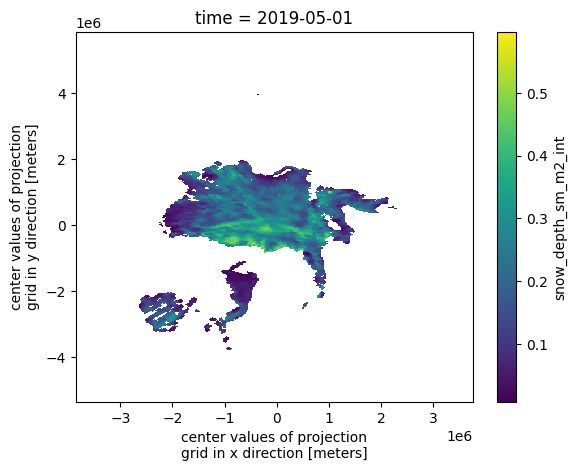

In [10]:
IS2SITMOGR4_summer_v0.snow_depth_sm_m2_int.isel(time=0).plot()

In [11]:
IS2SITMOGR4_summer_v0

<xarray.Dataset> Size: 193MB
Dimensions:                         (time: 11, y: 448, x: 304)
Coordinates:
  * time                            (time) datetime64[ns] 88B 2019-05-01 ... ...
    longitude                       (y, x) float32 545kB 168.3 168.1 ... -9.999
    latitude                        (y, x) float32 545kB 31.1 31.2 ... 34.47
  * x                               (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                               (y) float32 2kB 5.838e+06 ... -5.338e+06
Data variables: (12/33)
    crs                             (time) int32 44B -2147483647 ... -2147483647
    ice_thickness_sm_e5             (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_unc_freeboard     (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_ice_density   (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_density  (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_depth    (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                    (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                     (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [12]:
# Interpolate variables that still need it in the summer dataset
#interp_vars=[
# 'snow_depth_sm_m2',
# 'ice_thickness_sm_m2']

#IS2SITMOGR4_summer_v0 = apply_interpolation_time(IS2SITMOGR4_summer_v0, xptsIS2, yptsIS2, interp_vars)

In [13]:
IS2SITMOGR4_summer_v0

<xarray.Dataset> Size: 193MB
Dimensions:                         (time: 11, y: 448, x: 304)
Coordinates:
  * time                            (time) datetime64[ns] 88B 2019-05-01 ... ...
    longitude                       (y, x) float32 545kB 168.3 168.1 ... -9.999
    latitude                        (y, x) float32 545kB 31.1 31.2 ... 34.47
  * x                               (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                               (y) float32 2kB 5.838e+06 ... -5.338e+06
Data variables: (12/33)
    crs                             (time) int32 44B -2147483647 ... -2147483647
    ice_thickness_sm_e5             (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_unc_freeboard     (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_ice_density   (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_density  (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc_snow_depth    (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    sea_ice_conc                    (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    region_mask                     (time, y, x) float32 6MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [14]:
#rename_dict = {
#    'snow_depth_sm_e5': 'snow_depth_sm',
#    'snow_depth_sm_e5_int': 'snow_depth_sm_int',
#    'snow_density_sm_e5': 'snow_density_sm',
#    'ice_thickness_sm_e5': 'ice_thickness_sm',
#    'ice_thickness_sm_e5_int': 'ice_thickness_sm_int',
#    'ice_thickness_sm_e5_j22': 'ice_thickness_sm_j22',
#    'ice_thickness_sm_e5_j22_int': 'ice_thickness_sm_j22_int',
#    # Add more if needed
#}
#IS2SITMOGR4_summer_v0 = IS2SITMOGR4_summer_v0.rename(rename_dict)

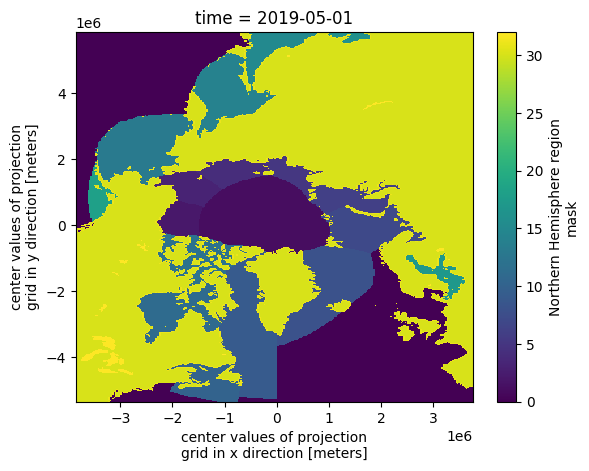

In [15]:
# Quick check it looks interpolated..!
IS2SITMOGR4_summer_v0.region_mask.isel(time=0).plot()

In [16]:
# Merge winter and summer IS-2 thickness data into one dataset
IS2SITMOGR4_allseason = IS2SITMOGR4_summer_v0.merge(IS2SITMOGR4_v3)

In [17]:
IS2SITMOGR4_allseason

<xarray.Dataset> Size: 774MB
Dimensions:                         (time: 33, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 264B 2018-11-01 ......
  * x                               (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                               (y) float32 2kB 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 545kB 168.3 168.1 ... -9.999
    latitude                        (y, x) float32 545kB 31.1 31.2 ... 34.47
Data variables: (12/44)
    crs                             (time) float64 264B -2.147e+09 ... -2.147...
    ice_thickness_sm_e5             (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    snow_depth_int                  (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_j22_int           (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99r                (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_mw99r             (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_depth_mw99r_int            (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_mw99r_int         (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [18]:
# Interpolate variables that still need it in the all-season dataset
interp_vars=[
 'snow_density',
 'snow_density_sm_e5',
 'snow_density_sm_m2',
 'snow_density_w99r',
 #'ice_thickness_sm_m2',
 #'ice_thickness_sm_j22',
 #'ice_thickness_sm_m2_j22',
 'ice_density_j22']

IS2SITMOGR4_allseason = apply_interpolation_time(IS2SITMOGR4_allseason, xptsIS2, yptsIS2, interp_vars)

Creating/forcing new variable snow_density_int
snow_density 0
Interpolated.
snow_density 1
Interpolated.
snow_density 2
Interpolated.
snow_density 3
Interpolated.
snow_density 4
Interpolated.
snow_density 5
Interpolated.
snow_density 6
no data or issue with gridding, so skipping...
snow_density 7
no data or issue with gridding, so skipping...
snow_density 8
no data or issue with gridding, so skipping...
snow_density 9
Interpolated.
snow_density 10
Interpolated.
snow_density 11
Interpolated.
snow_density 12
Interpolated.
snow_density 13
Interpolated.
snow_density 14
Interpolated.
snow_density 15
Interpolated.
snow_density 16
Interpolated.
snow_density 17
no data or issue with gridding, so skipping...
snow_density 18
no data or issue with gridding, so skipping...
snow_density 19
no data or issue with gridding, so skipping...
snow_density 20
no data or issue with gridding, so skipping...
snow_density 21
Interpolated.
snow_density 22
Interpolated.
snow_density 23
Interpolated.
snow_density

In [19]:
IS2SITMOGR4_allseason

<xarray.Dataset> Size: 864MB
Dimensions:                         (time: 33, x: 304, y: 448)
Coordinates:
  * time                            (time) datetime64[ns] 264B 2018-11-01 ......
  * x                               (x) float32 1kB -3.838e+06 ... 3.738e+06
  * y                               (y) float32 2kB 5.838e+06 ... -5.338e+06
    longitude                       (y, x) float32 545kB 168.3 168.1 ... -9.999
    latitude                        (y, x) float32 545kB 31.1 31.2 ... 34.47
Data variables: (12/49)
    crs                             (time) float64 264B -2.147e+09 ... -2.147...
    ice_thickness_sm_e5             (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_sm_m2             (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ice_thickness_unc               (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    num_segments                    (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    mean_day_of_month               (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    ...                              ...
    ice_thickness_mw99r_int         (time, y, x) float32 18MB dask.array<chunksize=(1, 448, 304), meta=np.ndarray>
    snow_density_int                (time, y, x) float32 18MB nan nan ... nan
    snow_density_sm_e5_int          (time, y, x) float32 18MB nan nan ... nan
    snow_density_sm_m2_int          (time, y, x) float32 18MB nan nan ... nan
    snow_density_w99r_int           (time, y, x) float32 18MB nan nan ... nan
    ice_density_j22_int             (time, y, x) float32 18MB nan nan ... nan
Attributes:
    contact:      Alek Petty (akpetty@umd.edu)
    description:  Aggregated IS2SITMOGR4 summer V1 dataset.
    history:      Created 23/07/25

In [20]:
# Get UBRIS/UIT CS-2 data
start_date_cs2 = "Oct 2018"
end_date_cs2 = "July 2021"
# NB: MS indicates a time frequency of start of the month
date_range_cs2 = pd.date_range(start=start_date_cs2, end=end_date_cs2, freq='MS') 

# Re-grid the UBRIS/UIT CS-2 data to the IS-2 grid.
# Includes monthly resampling of the biweekly data
cs2_ubris = regrid_ubris_to_is2(mapProj, xIS2, yIS2, out_lons, out_lats, date_range_cs2,
                             dataPathCS2=current_directory+'/data/', dataset='uit_cryosat2_seaicethickness_nh_80km_v1p7.nc')

# Relabel the cs2_sea_ice_thickness_UBRIS variable to ice_thickness_cs2_ubris
cs2_ubris = cs2_ubris.rename({'cs2_sea_ice_thickness_UBRIS': 'ice_thickness_cs2_ubris'})


In [21]:
# Get the preliminary IS-2/CS-2 winter snow depths, downlaoded from Zenodo
cs2is2_snow_regridded_da = get_cs2is2_snow(mapProj, xIS2, yIS2, dataPathCS2=current_directory+'/data/uit_cs2-is2-ak_snow_depth_25km_v3.nc')

In [22]:
# Merge with other CS-2 data
cs2_ubris = cs2_ubris.merge({'cs2is2_snow_depth': cs2is2_snow_regridded_da})

In [23]:
# Merge all season IS-2 data and CS-2 datasets
IS2_CS2_allseason = IS2SITMOGR4_allseason.merge(cs2_ubris)

# Adjust all times to the middle (15th) of the month for plotting purposes
# (generally time defaults to the start of the month, with the MS function)
IS2_CS2_allseason['time'] = IS2_CS2_allseason['time'] + pd.Timedelta(days=14)

In [24]:
# Remove data outside of the period coincident with the SM-LG/IS-2 data
IS2_CS2_allseason = IS2_CS2_allseason.where(IS2_CS2_allseason['time'] <= pd.Timestamp('2021-07-20'), drop=True)
IS2_CS2_allseason = IS2_CS2_allseason.where(IS2_CS2_allseason['time'] >= pd.Timestamp('2018-11-01'), drop=True)
#IS2_CS2_allseason

In [25]:
# Only need the region mask for the first time step (missing from time=0 for some reason...)
IS2_CS2_allseason['region_mask'] = IS2_CS2_allseason['region_mask'].isel(time=1, drop=True)

In [27]:
# Save the dataset to netCDF file
output_path = './data/book_data_allseason_v2.nc'
IS2_CS2_allseason.to_netcdf(output_path)

print(f"Dataset saved to {output_path}")

Dataset saved to ./data/book_data_allseason_v2.nc


In [28]:
# Test loading the saved file
test_load = xr.open_dataset('./data/book_data_allseason_v2.nc')
print("Successfully loaded saved dataset")

Successfully loaded saved dataset
